# Stage Transition Model

**Goal:** At each stage transition, predict:
- `P(advances to next stage | current stage)` 
- `P(lost | current stage) = 1 - P(advances)`

Dataset: `stage_transitions_model.csv` — one row per actual stage transition from stages 1-7, labeled `advanced=1` (moved forward) or `advanced=0` (moved to closed-lost).

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import GroupKFold
from sklearn.metrics import (
    average_precision_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    brier_score_loss,
    classification_report,
    precision_recall_curve
)
from sklearn.calibration import calibration_curve
from catboost import CatBoostClassifier

In [2]:
df = pd.read_csv("stage_transitions_model.csv")
print(f"Rows: {len(df)}, Unique opps: {df['opportunity_id'].nunique()}")
display(df.head())

Rows: 3969, Unique opps: 3091


,opportunity_id,display_id,snapshot_version,snapshot_date,current_stage,next_stage,opportunity_type,segment,days_in_current_stage,days_in_sales_cycle,stall_ratio,has_champion,contract_length,advanced,meetings_conducted
0,don:core:dvrv-us-1:devo/0:opportunity/10000,OPP-10000,213,2026-07-14 18:39:24.051,3-evaluate,9-closed_lost,New,Enterprise,76.0,134.0,0.567164,1.0,12.0,0,1.0
1,don:core:dvrv-us-1:devo/0:opportunity/10002,OPP-10002,103,2026-05-26 03:49:58.517,1-profile,9-closed_lost,New,Mid-Market,84.0,84.0,1.000000,0.0,12.0,0,1.0
2,don:core:dvrv-us-1:devo/0:opportunity/10006,OPP-10006,141,2026-05-27 13:55:54.875,3-evaluate,5-validate,New,SMB,86.0,86.0,1.000000,1.0,36.0,1,0.0
3,don:core:dvrv-us-1:devo/0:opportunity/10011,OPP-10011,79,2026-05-14 00:21:52.017,1-profile,9-closed_lost,New,Enterprise,71.0,71.0,1.000000,0.0,12.0,0,0.0
4,don:core:dvrv-us-1:devo/0:opportunity/10014,OPP-10014,238,2026-06-17 04:58:42.848,3-evaluate,5-validate,New,Enterprise,54.0,105.0,0.514286,1.0,12.0,1,3.0


In [3]:
print("\nLabel distribution:")
print(df["advanced"].value_counts())
print(f"\nAdvance rate: {df['advanced'].mean():.3f}")


Label distribution:
advanced
0    2492
1    1476
4       1
Name: count, dtype: int64

Advance rate: 0.373


In [4]:
print("\nBy current stage:")
display(
    df.groupby("current_stage")["advanced"]
      .agg(["count", "sum", "mean"])
      .rename(columns={"count": "transitions", "sum": "advanced", "mean": "advance_rate"})
      .sort_index()
)


By current stage:


,transitions,advanced,advance_rate
current_stage,,,
1-profile,2626,893,0.340061
2-qualify,629,209,0.332273
3-evaluate,370,135,0.364865
4-go_no_go,93,57,0.612903
5-validate,101,63,0.623762
6-negotiate,83,55,0.662651
7-submit_for_close,66,64,0.969697
9-closed_lost,1,4,4.000000


In [5]:
print("\nMissing values:")
print(df.isnull().sum().sort_values(ascending=False))


Missing values:
days_in_current_stage    462
days_in_sales_cycle      462
segment                  267
opportunity_id             1
meetings_conducted         1
display_id                 0
snapshot_version           0
snapshot_date              0
current_stage              0
next_stage                 0
opportunity_type           0
stall_ratio                0
has_champion               0
contract_length            0
advanced                   0
dtype: int64


## Feature Setup

In [6]:
# Clean: drop rows with NaN opportunity_id or invalid advanced values
df = df[df["opportunity_id"].notna()].reset_index(drop=True)
df = df[df["advanced"].isin([0, 1])].reset_index(drop=True)
print(f"After cleaning: {len(df)} rows, {df['opportunity_id'].nunique()} opps")

feature_columns = [
    "current_stage",
    "opportunity_type",
    "segment",
    "stall_ratio",
    "has_champion",
    "contract_length",
    "days_in_current_stage",
    "days_in_sales_cycle",
    "meetings_conducted",
]

categorical_features = ["current_stage", "opportunity_type", "segment"]
numeric_features = [
    "stall_ratio", "has_champion", "contract_length",
    "days_in_current_stage", "days_in_sales_cycle",
    "meetings_conducted"
]

X = df[feature_columns].copy()
y = df["advanced"].astype(int)
groups = df["opportunity_id"]

# CatBoost prep
for col in categorical_features:
    X[col] = X[col].fillna("UNKNOWN").astype(str)

for col in numeric_features:
    X[col] = pd.to_numeric(X[col], errors="coerce")

print(f"X: {X.shape}, y: {y.shape}")
print(f"Groups: {groups.nunique()} unique opportunities")

After cleaning: 3968 rows, 3091 opps
X: (3968, 9), y: (3968,)
Groups: 3091 unique opportunities


## Cross-Validation (GroupKFold)

In [7]:
gkf = GroupKFold(n_splits=5)
folds = list(gkf.split(X, y, groups))

for fold_num, (train_idx, test_idx) in enumerate(folds, 1):
    train_opps = set(groups.iloc[train_idx])
    test_opps = set(groups.iloc[test_idx])
    overlap = train_opps & test_opps
    print(f"Fold {fold_num}: train={len(train_opps)} opps, test={len(test_opps)} opps, overlap={len(overlap)}")

Fold 1: train=2473 opps, test=618 opps, overlap=0
Fold 2: train=2473 opps, test=618 opps, overlap=0
Fold 3: train=2472 opps, test=619 opps, overlap=0
Fold 4: train=2473 opps, test=618 opps, overlap=0
Fold 5: train=2473 opps, test=618 opps, overlap=0


## CatBoost Training

In [8]:
results = []
all_oof = []

for fold_num, (train_idx, test_idx) in enumerate(folds, 1):
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

    model = CatBoostClassifier(
        iterations=500,
        depth=5,
        learning_rate=0.03,
        loss_function="Logloss",
        eval_metric="PRAUC",
        auto_class_weights="Balanced",
        l2_leaf_reg=5,
        random_seed=42,
        verbose=False,
    )

    model.fit(X_train, y_train, cat_features=categorical_features)

    probs = model.predict_proba(X_test)[:, 1]  # P(advanced)
    preds = (probs >= 0.5).astype(int)

    metrics = {
        "fold": fold_num,
        "PR_AUC": average_precision_score(y_test, probs),
        "ROC_AUC": roc_auc_score(y_test, probs),
        "Precision": precision_score(y_test, preds, zero_division=0),
        "Recall": recall_score(y_test, preds, zero_division=0),
        "F1": f1_score(y_test, preds, zero_division=0),
        "Brier": brier_score_loss(y_test, probs),
    }
    results.append(metrics)

    all_oof.append(pd.DataFrame({
        "opportunity_id": groups.iloc[test_idx].values,
        "current_stage": df["current_stage"].iloc[test_idx].values,
        "actual": y_test.values,
        "p_advance": probs,
        "p_lost": 1 - probs,
        "fold": fold_num,
    }))

results_df = pd.DataFrame(results)
display(results_df)

,fold,PR_AUC,ROC_AUC,Precision,Recall,F1,Brier
0,1,0.851973,0.897339,0.718654,0.810345,0.761750,0.130662
1,2,0.856400,0.893240,0.739130,0.782895,0.760383,0.131707
2,3,0.851484,0.897865,0.750799,0.793919,0.771757,0.126636
3,4,0.805674,0.876485,0.723684,0.771930,0.747029,0.139930
4,5,0.845388,0.890443,0.756849,0.734219,0.745363,0.130397


In [9]:
print("\nMean ± Std:")
display(results_df[["PR_AUC","ROC_AUC","Precision","Recall","F1","Brier"]].agg(["mean","std"]))


Mean ± Std:


,PR_AUC,ROC_AUC,Precision,Recall,F1,Brier
mean,0.842184,0.891074,0.737823,0.778662,0.757256,0.131866
std,0.020783,0.008708,0.016579,0.028614,0.011026,0.004899


## Feature Importance

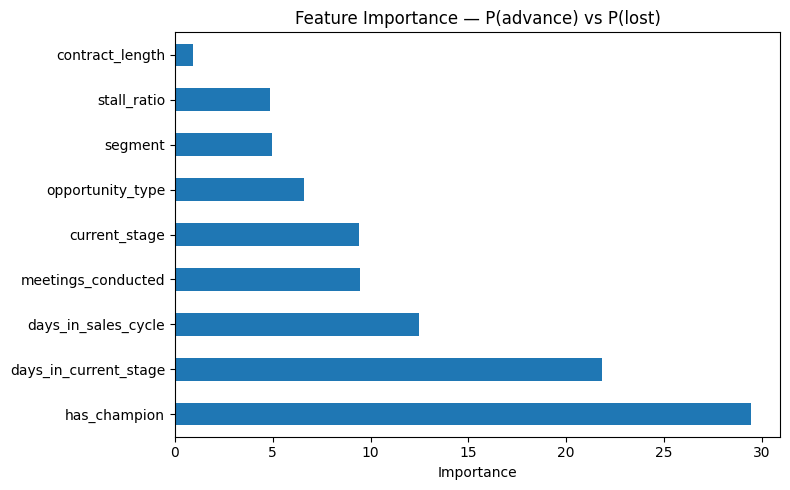

has_champion             29.453862
days_in_current_stage    21.812093
days_in_sales_cycle      12.495949
meetings_conducted        9.472861
current_stage             9.411126
opportunity_type          6.583922
segment                   4.971165
stall_ratio               4.881664
contract_length           0.917358
dtype: float64


In [10]:
# Retrain on full data for feature importance
final_model = CatBoostClassifier(
    iterations=500,
    depth=5,
    learning_rate=0.03,
    loss_function="Logloss",
    eval_metric="PRAUC",
    auto_class_weights="Balanced",
    l2_leaf_reg=5,
    random_seed=42,
    verbose=False,
)
final_model.fit(X, y, cat_features=categorical_features)

importance = pd.Series(
    final_model.feature_importances_,
    index=feature_columns
).sort_values(ascending=False)

plt.figure(figsize=(8, 5))
importance.plot(kind="barh")
plt.xlabel("Importance")
plt.title("Feature Importance — P(advance) vs P(lost)")
plt.tight_layout()
plt.show()

print(importance)

## Calibration

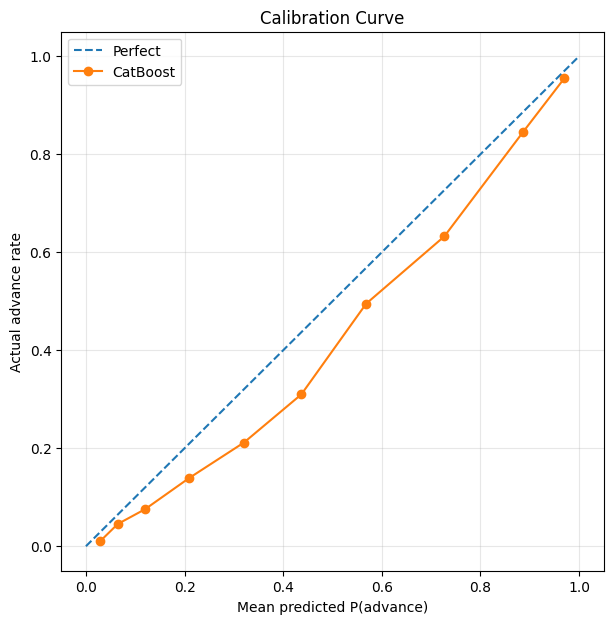

Overall Brier: 0.1319


In [11]:
oof_df = pd.concat(all_oof, ignore_index=True)

# Calibration curve
prob_true, prob_pred = calibration_curve(
    oof_df["actual"], oof_df["p_advance"], n_bins=10, strategy="quantile"
)

plt.figure(figsize=(7, 7))
plt.plot([0, 1], [0, 1], "--", label="Perfect")
plt.plot(prob_pred, prob_true, "o-", label="CatBoost")
plt.xlabel("Mean predicted P(advance)")
plt.ylabel("Actual advance rate")
plt.title("Calibration Curve")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

print(f"Overall Brier: {brier_score_loss(oof_df['actual'], oof_df['p_advance']):.4f}")

## Per-Stage Predictions

In [12]:
stage_perf = (
    oof_df.groupby("current_stage")
    .agg(
        n=("actual", "size"),
        actual_advance_rate=("actual", "mean"),
        mean_p_advance=("p_advance", "mean"),
        mean_p_lost=("p_lost", "mean"),
    )
    .sort_index()
)
display(stage_perf)

,n,actual_advance_rate,mean_p_advance,mean_p_lost
current_stage,,,,
1-profile,2626,0.340061,0.395532,0.604468
2-qualify,629,0.332273,0.423141,0.576859
3-evaluate,370,0.364865,0.433684,0.566316
4-go_no_go,93,0.612903,0.701493,0.298507
5-validate,101,0.623762,0.698407,0.301593
6-negotiate,83,0.662651,0.697024,0.302976
7-submit_for_close,66,0.969697,0.904361,0.095639


In [13]:
# Output: two-column prediction table
print("\nSample predictions (P(advance) and P(lost) per transition):")
display(oof_df[["opportunity_id","current_stage","actual","p_advance","p_lost"]].head(15))


Sample predictions (P(advance) and P(lost) per transition):


,opportunity_id,current_stage,actual,p_advance,p_lost
0,don:core:dvrv-us-1:devo/0:opportunity/10019,1-profile,0,0.060718,0.939282
1,don:core:dvrv-us-1:devo/0:opportunity/10032,2-qualify,0,0.100109,0.899891
2,don:core:dvrv-us-1:devo/0:opportunity/10036,5-validate,1,0.754168,0.245832
3,don:core:dvrv-us-1:devo/0:opportunity/10036,6-negotiate,1,0.891582,0.108418
4,don:core:dvrv-us-1:devo/0:opportunity/10036,7-submit_for_close,1,0.971061,0.028939
5,don:core:dvrv-us-1:devo/0:opportunity/10050,2-qualify,0,0.115451,0.884549
6,don:core:dvrv-us-1:devo/0:opportunity/10055,1-profile,0,0.020343,0.979657
7,don:core:dvrv-us-1:devo/0:opportunity/10060,3-evaluate,0,0.167198,0.832802
8,don:core:dvrv-us-1:devo/0:opportunity/10070,1-profile,0,0.020715,0.979285
9,don:core:dvrv-us-1:devo/0:opportunity/10082,3-evaluate,0,0.198400,0.801600
